Mounted at /content/drive

📌 PASO 11: Evaluación del modelo funcional con matriz de distancias
📊 Muestra: 100% | k = 3 | λ = 4.3443
🧮 Top 3 variables con mayor peso: AFT, PPI, RAF


🔁 Folds validación:   0%|          | 0/10 [00:00<?, ?it/s]

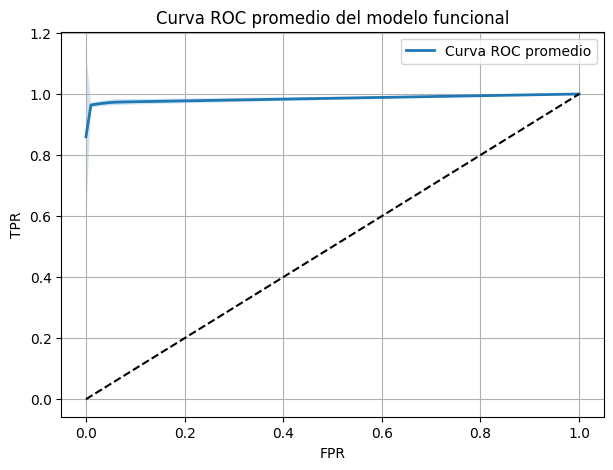

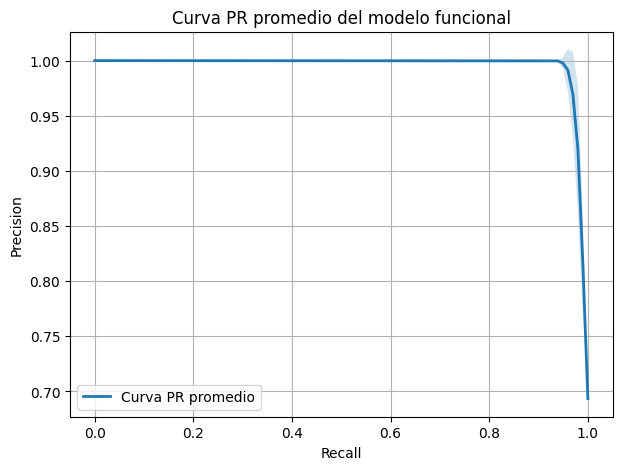

,Accuracy,Precision,Recall,F1-score,AUC,Log Loss,k,lambda,Top 1 variable,Top 2 variable,Top 3 variable,Observación
0,0.9730 ±0.0064,0.9976 ±0.0019,0.9635 ±0.0086,0.9802 ±0.0048,0.9854 ±0.0051,0.6860 ±0.2272,3,4.344263,"AFT (peso bruto: 4.556, normalizado: 8.6%)","PPI (peso bruto: 4.360, normalizado: 8.2%)","RAF (peso bruto: 4.289, normalizado: 8.1%)",Muy alto / excelente desempeño. Buena estabili...


In [1]:
# 🚗 Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 📚 Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, log_loss,
    precision_recall_curve, average_precision_score
)
import os

# 📍 Rutas actualizadas
ruta_base = "/content/drive/MyDrive/Datos/20_1EspacioF.parquet"
ruta_parametros = "/content/drive/MyDrive/Datos/20_2ParametrosFuncional.pkl"
ruta_matriz = "/content/drive/MyDrive/Datos/21_Matriz_Distancias_Funcional.npy"
ruta_nits = "/content/drive/MyDrive/Datos/21_Orden_NITs_Funcional.npy"

# 📍 Rutas de salida actualizadas (evitar sobrescribir las del bloque 11)
ruta_resultados     = "/content/drive/MyDrive/Resultados/22_1_Resultados_Modelo_Funcional.pkl"
ruta_roc            = "/content/drive/MyDrive/Resultados/22_2_ROC_Folds.pkl"
ruta_prc            = "/content/drive/MyDrive/Resultados/22_3_PRC_Folds.pkl"
ruta_radar          = "/content/drive/MyDrive/Resultados/22_4_Radar_Pesos_Indicadores.png"
ruta_predicciones   = "/content/drive/MyDrive/Resultados/22_5_Errores_Por_Empresa_Funcional.parquet"
ruta_sector         = "/content/drive/MyDrive/Resultados/22_7_Heatmap_Errores_CIIU_Nombres.png"
ruta_departamento   = "/content/drive/MyDrive/Resultados/22_8_Heatmap_Errores_Departamentos.png"

# 💾 Cargar datos y parámetros
df = pd.read_parquet(ruta_base)
with open(ruta_parametros, "rb") as f:
    parametros = pickle.load(f)
matriz_dist = np.load(ruta_matriz)
nits_orden = np.load(ruta_nits, allow_pickle=True)

# 🧮 Extraer parámetros
k_final = parametros["k"]
lambda_final = parametros["lambda"]
pesos_finales = parametros["pesos"]
top3_final = parametros["top3"]
n_ventana = 5
suma_pesos = sum(pesos_finales.values())
pesos_normalizados = {var: peso / suma_pesos for var, peso in pesos_finales.items()}
indicadores = sorted(p for p in pesos_normalizados.keys() if p not in ["DEP", "CIIU", "desfase"])

# 🎯 Asegurar orden de empresas
df = df[df["RQ_final"].notna()].copy()
if "NIT" in df.columns:
    df = df.set_index("NIT", drop=False)
df = df.loc[nits_orden]
y = df["RQ_final"].values
NITs = df.index.tolist()

# 🔁 Validación cruzada
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracy_list, precision_list, recall_list, f1_list, auc_list, logloss_list = [], [], [], [], [], []
roc_data, prc_data, avg_precisions = [], [], []

print(f"\n📌 PASO 11: Evaluación del modelo funcional con matriz de distancias")
print(f"📊 Muestra: 100% | k = {k_final} | λ = {lambda_final:.4f}")
print(f"🧮 Top 3 variables con mayor peso: {', '.join([v[0] for v in top3_final])}")

for fold, (train_idx, test_idx) in enumerate(tqdm(skf.split(matriz_dist, y), total=10, desc="🔁 Folds validación")):
    y_train, y_test = y[train_idx], y[test_idx]
    preds, probs = [], []
    for i in test_idx:
        distancias = [(matriz_dist[i, j], y[j]) for j in train_idx]
        vecinos = sorted(distancias, key=lambda x: x[0])[:k_final]
        proba = np.mean([v[1] for v in vecinos])
        preds.append(round(proba))
        probs.append(proba)

    accuracy_list.append(accuracy_score(y_test, preds))
    precision_list.append(precision_score(y_test, preds, zero_division=0))
    recall_list.append(recall_score(y_test, preds))
    f1_list.append(f1_score(y_test, preds))
    auc_list.append(roc_auc_score(y_test, probs))
    logloss_list.append(log_loss(y_test, probs))

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_data.append({"fold": fold+1, "fpr": fpr, "tpr": tpr})
    precision, recall, _ = precision_recall_curve(y_test, probs)
    avg_precisions.append(average_precision_score(y_test, probs))
    prc_data.append({"fold": fold+1, "precision": precision, "recall": recall})

# 📈 Curva ROC promedio
mean_fpr = np.linspace(0, 1, 100)
tprs = [np.interp(mean_fpr, r["fpr"], r["tpr"]) for r in roc_data]
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_tpr[-1] = 1.0
plt.figure(figsize=(7, 5))
plt.plot(mean_fpr, mean_tpr, label='Curva ROC promedio', linewidth=2)
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, alpha=0.2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC promedio del modelo funcional")
plt.grid(True)
plt.legend()
plt.show()

# 📉 Curva PR promedio
mean_recall = np.linspace(0, 1, 100)
precisions_interp = [np.interp(mean_recall, r["recall"][::-1], r["precision"][::-1]) for r in prc_data]
mean_precision = np.mean(precisions_interp, axis=0)
std_precision = np.std(precisions_interp, axis=0)
plt.figure(figsize=(7, 5))
plt.plot(mean_recall, mean_precision, label='Curva PR promedio', linewidth=2)
plt.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision, alpha=0.2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva PR promedio del modelo funcional")
plt.grid(True)
plt.legend()
plt.show()

# 📋 Resumen final
f1_mean = np.mean(f1_list)
f1_std = np.std(f1_list)
desempeno = "Muy alto / excelente desempeño" if f1_mean >= 0.95 else \
            "Alto desempeño" if f1_mean >= 0.85 else \
            "Desempeño moderado" if f1_mean >= 0.70 else \
            "Bajo desempeño" if f1_mean >= 0.50 else "Muy bajo desempeño"
robustez = "Altamente robusto y estable" if f1_std <= 0.0003 else \
           "Muy estable" if f1_std <= 0.002 else \
           "Buena estabilidad" if f1_std <= 0.007 else \
           "Variabilidad moderada" if f1_std <= 0.015 else "Alta variabilidad / menos robusto"
observacion = f"{desempeno}. {robustez}."

top3_bruto_normalizado = [
    f"{var} (peso bruto: {peso_bruto:.3f}, normalizado: {pesos_normalizados[var]*100:.1f}%)"
    for var, peso_bruto in top3_final
]

resumen_final = {
    "Accuracy": f"{np.mean(accuracy_list):.4f} ±{np.std(accuracy_list):.4f}",
    "Precision": f"{np.mean(precision_list):.4f} ±{np.std(precision_list):.4f}",
    "Recall": f"{np.mean(recall_list):.4f} ±{np.std(recall_list):.4f}",
    "F1-score": f"{f1_mean:.4f} ±{f1_std:.4f}",
    "AUC": f"{np.mean(auc_list):.4f} ±{np.std(auc_list):.4f}",
    "Log Loss": f"{np.mean(logloss_list):.4f} ±{np.std(logloss_list):.4f}",
    "k": k_final,
    "lambda": lambda_final,
    "Top 1 variable": top3_bruto_normalizado[0],
    "Top 2 variable": top3_bruto_normalizado[1],
    "Top 3 variable": top3_bruto_normalizado[2],
    "Observación": observacion
}

display(pd.DataFrame([resumen_final]))

# 💾 Guardar resultados
os.makedirs("/content/drive/MyDrive/Resultados", exist_ok=True)
with open(ruta_resultados, "wb") as f:
    pickle.dump({
        "resumen": resumen_final,
        "folds_accuracy": accuracy_list,
        "folds_precision": precision_list,
        "folds_recall": recall_list,
        "folds_f1": f1_list,
        "folds_auc": auc_list,
        "folds_logloss": logloss_list,
        "folds_avg_precision": avg_precisions,
        "params": {"k": k_final, "lambda": lambda_final, "pesos": pesos_finales, "top3": top3_final},
        "nits": NITs
    }, f)
with open(ruta_roc, "wb") as f:
    pickle.dump(roc_data, f)
with open(ruta_prc, "wb") as f:
    pickle.dump(prc_data, f)
